In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [3]:
stock_date= yf.download("AAPL", start="2010-1-1")
stock_date.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.406480,6.421148,6.357685,6.389117,493729600
2010-01-05,6.417556,6.453778,6.383729,6.424142,601904800
2010-01-06,6.315478,6.443003,6.308892,6.417558,552160000
2010-01-07,6.303801,6.346310,6.258000,6.338826,477131200
2010-01-08,6.345711,6.346310,6.258301,6.295420,447610800


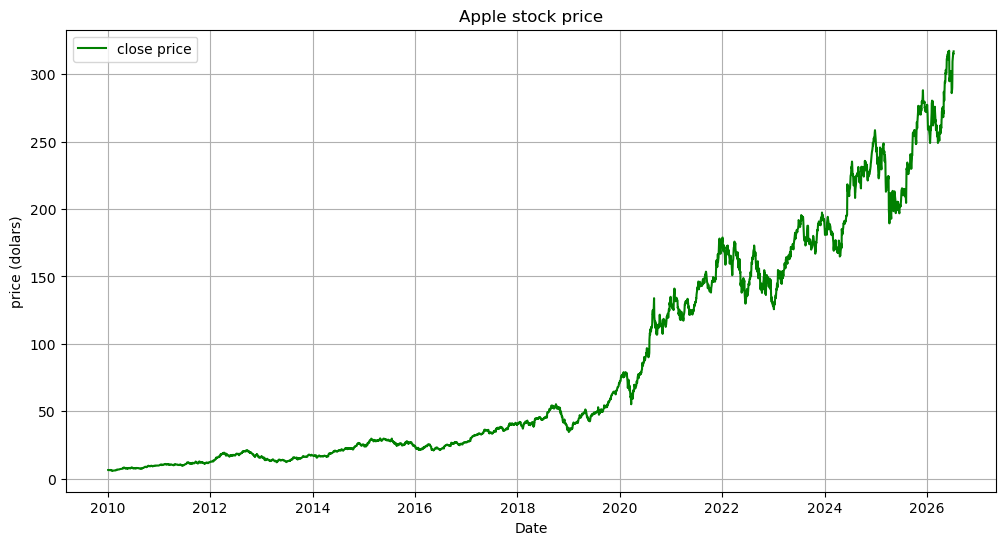

In [4]:
plt.figure(figsize=(12,6))
plt.plot(stock_date.index,stock_date["High"],label="close price",color="green")
plt.title("Apple stock price")
plt.xlabel("Date")
plt.ylabel("price (dolars)")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose 

In [6]:
additive_model=seasonal_decompose(stock_date["Close"],model="additive",period=30)

In [7]:
trend_additive=additive_model.trend
seasonal_additive=additive_model.seasonal
noise_additive=additive_model.resid

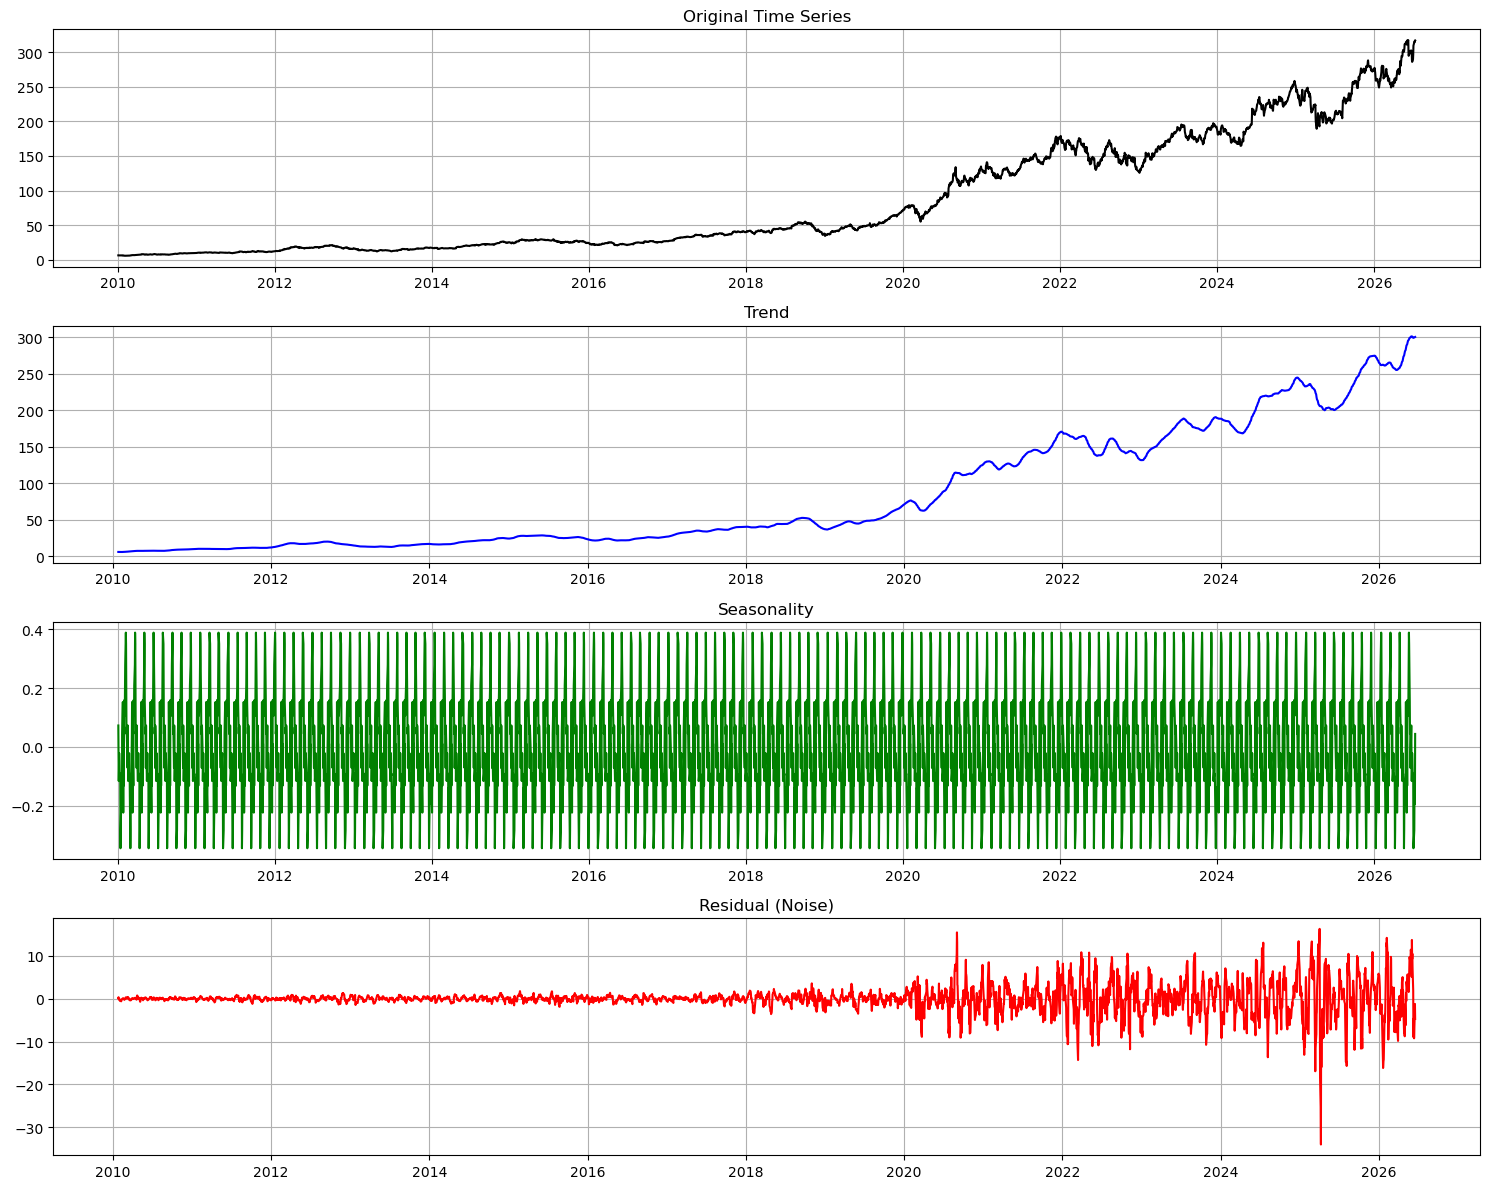

In [8]:
plt.figure(figsize=(15,12))

# Original Data
plt.subplot(4,1,1)
plt.plot(stock_date["High"], color='black')
plt.title("Original Time Series")
plt.grid(True)

# Trend
plt.subplot(4,1,2)
plt.plot(trend_additive, color='blue')
plt.title("Trend")
plt.grid(True)

# Seasonality
plt.subplot(4,1,3)
plt.plot(seasonal_additive, color='green')
plt.title("Seasonality")
plt.grid(True)

# Residual
plt.subplot(4,1,4)
plt.plot(noise_additive, color='red')
plt.title("Residual (Noise)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [9]:
from statsmodels.tsa.seasonal import STL 

In [10]:
STL_model=STL(stock_date["Close"],period=30)

In [11]:
result=STL_model.fit()

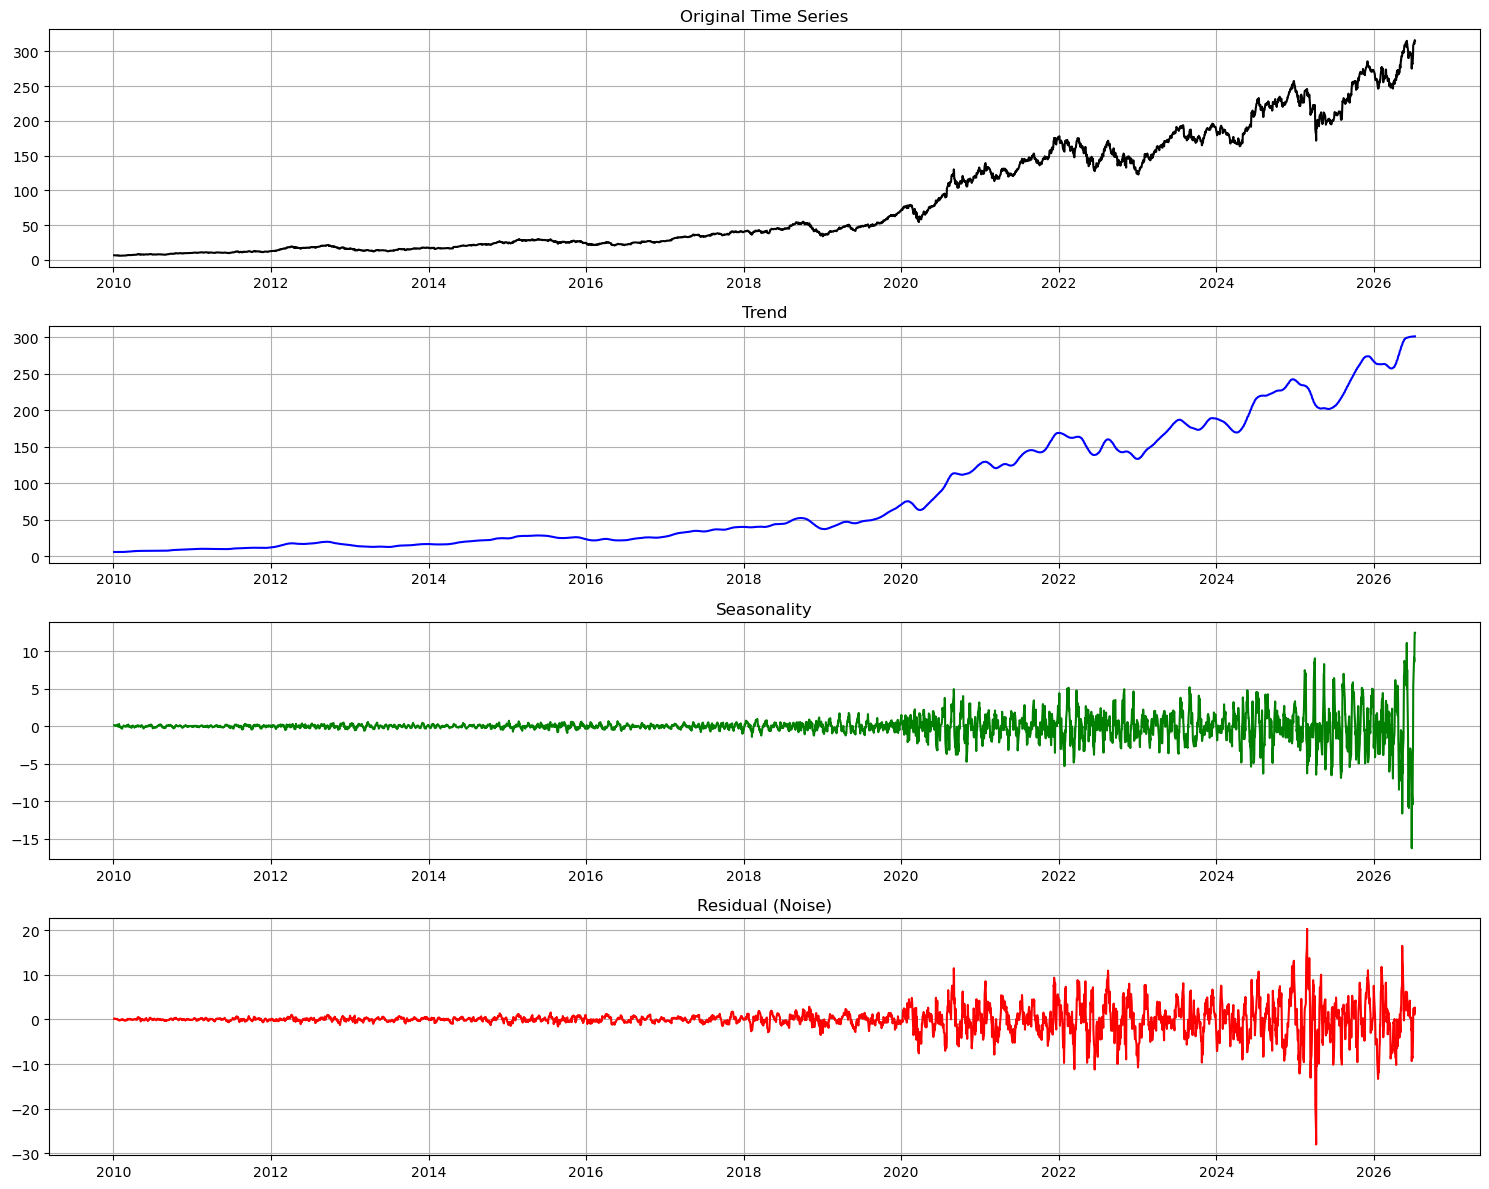

In [12]:
plt.figure(figsize=(15,12))

# Original Data
plt.subplot(4,1,1)
plt.plot(result.observed, color='black')
plt.title("Original Time Series")
plt.grid(True)

# Trend
plt.subplot(4,1,2)
plt.plot(result.trend, color='blue')
plt.title("Trend")
plt.grid(True)

# Seasonality
plt.subplot(4,1,3)
plt.plot(result.seasonal, color='green')
plt.title("Seasonality")
plt.grid(True)

# Residual
plt.subplot(4,1,4)
plt.plot(result.resid, color='red')
plt.title("Residual (Noise)")
plt.grid(True)

plt.tight_layout()
plt.show()

# Stationery Test 

In [14]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF Test
result = adfuller(stock_date['Close'].dropna())

print("ADF Statistic :", result[0])
print("p-value :", result[1])
print("Number of Lags Used :", result[2])
print("Number of Observations Used :", result[3])

print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key} : {value}")

# Conclusion
if result[1] < 0.05:
    print("\nConclusion: The series is Stationary.")
else:
    print("\nConclusion: The series is NOT Stationary.")

ADF Statistic : 1.767723855321748
p-value : 0.9982828076415682
Number of Lags Used : 18
Number of Observations Used : 4135

Critical Values:
1% : -3.431932433890647
5% : -2.8622392324749026
10% : -2.567142207816893

Conclusion: The series is NOT Stationary.


# ADF TEST

In [15]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF Test
result = adfuller(stock_date['Close'].dropna())

print("ADF Statistic :", result[0])
print("p-value :", result[1])
print("Number of Lags Used :", result[2])
print("Number of Observations Used :", result[3])

print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key} : {value}")

# Conclusion
if result[1] < 0.05:
    print("\nConclusion: The series is Stationary.")
else:
    print("\nConclusion: The series is NOT Stationary.")

ADF Statistic : 1.767723855321748
p-value : 0.9982828076415682
Number of Lags Used : 18
Number of Observations Used : 4135

Critical Values:
1% : -3.431932433890647
5% : -2.8622392324749026
10% : -2.567142207816893

Conclusion: The series is NOT Stationary.


# KPSS TEST

In [16]:
from statsmodels.tsa.stattools import kpss

# Perform KPSS Test
result = kpss(stock_date['Close'].dropna(), regression='c')

print("KPSS Statistic :", result[0])
print("p-value :", result[1])
print("Number of Lags Used :", result[2])

print("\nCritical Values:")
for key, value in result[3].items():
    print(f"{key} : {value}")

# Conclusion
if result[1] < 0.05:
    print("\nConclusion: The series is NOT Stationary.")
else:
    print("\nConclusion: The series is Stationary.")

KPSS Statistic : 8.92193708600876
p-value : 0.01
Number of Lags Used : 40

Critical Values:
10% : 0.347
5% : 0.463
2.5% : 0.574
1% : 0.739

Conclusion: The series is NOT Stationary.


C:\Users\karth\AppData\Local\Temp\ipykernel_3940\3603451771.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(stock_date['Close'].dropna(), regression='c')


# KP TEST

In [17]:
# Import the KPSS test function from statsmodels
from statsmodels.tsa.stattools import kpss

# Run the KPSS test on the 'Close' column
# dropna() removes any missing (NaN) values
# regression='c' tests for level stationarity (constant mean)
result = kpss(stock_date['Close'].dropna(), regression='c')

# Print the KPSS test statistic
print("KPSS Statistic :", result[0])

# Print the p-value
print("p-value :", result[1])

# Print the number of lags used in the test
print("Number of Lags Used :", result[2])

# Print the heading for critical values
print("\nCritical Values:")

# Loop through the critical values dictionary
# key = significance level (1%, 5%, 10%, etc.)
# value = corresponding critical value
for key, value in result[3].items():
    print(f"{key} : {value}")

# Check the p-value to determine stationarity
# Null Hypothesis (H0): The series is stationary
if result[1] < 0.05:
    # Reject the null hypothesis
    print("\nConclusion: The series is NOT Stationary.")
else:
    # Fail to reject the null hypothesis
    print("\nConclusion: The series is Stationary.")

KPSS Statistic : 8.92193708600876
p-value : 0.01
Number of Lags Used : 40

Critical Values:
10% : 0.347
5% : 0.463
2.5% : 0.574
1% : 0.739

Conclusion: The series is NOT Stationary.


C:\Users\karth\AppData\Local\Temp\ipykernel_3940\630822620.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(stock_date['Close'].dropna(), regression='c')


# making data stationery

In [38]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    """
    Perform Augmented Dickey-Fuller (ADF) Test

    H0: The series is NOT stationary (has a unit root)
    H1: The series is stationary
    """

    # Convert NumPy array to Pandas Series
    if isinstance(series, np.ndarray):
        series = pd.Series(series)

    # Remove missing values
    series = series.dropna()

    # Perform ADF Test
    result = adfuller(series)

    print("=" * 50)
    print("Augmented Dickey-Fuller (ADF) Test")
    print("=" * 50)

    print(f"ADF Statistic           : {result[0]:.6f}")
    print(f"p-value                 : {result[1]:.6f}")
    print(f"Number of Lags Used     : {result[2]}")
    print(f"Number of Observations  : {result[3]}")

    print("\nCritical Values:")
    for key, value in result[4].items():
        print(f"{key:>5} : {value:.6f}")

    if result[1] < 0.05:
        print("\nConclusion: ✅ Series is Stationary (Reject H0)")
    else:
        print("\nConclusion: ❌ Series is NOT Stationary (Fail to Reject H0)")

In [39]:
from statsmodels.tsa.stattools import kpss

def kpss_test(series):
    """
    Perform KPSS Test

    H0: The series is stationary
    H1: The series is NOT stationary
    """

    result = kpss(series.dropna(), regression='c')

    print("=" * 50)
    print("KPSS Test")
    print("=" * 50)

    print(f"KPSS Statistic          : {result[0]}")
    print(f"p-value                 : {result[1]}")
    print(f"Number of Lags Used     : {result[2]}")

    print("\nCritical Values:")
    for key, value in result[3].items():
        print(f"   {key} : {value}")

    if result[1] < 0.05:
        print("\nConclusion: ❌ Series is NOT Stationary (Reject H0)")
    else:
        print("\nConclusion: ✅ Series is Stationary (Fail to Reject H0)")

In [40]:
price=stock_date["Close"]["AAPL"]
adf_test(price)

Augmented Dickey-Fuller (ADF) Test
ADF Statistic           : 1.767724
p-value                 : 0.998283
Number of Lags Used     : 18
Number of Observations  : 4135

Critical Values:
   1% : -3.431932
   5% : -2.862239
  10% : -2.567142

Conclusion: ❌ Series is NOT Stationary (Fail to Reject H0)


In [48]:
diff=price.diff()
diff

Date
2010-01-04         NaN
2010-01-05    0.011076
2010-01-06   -0.102078
2010-01-07   -0.011677
2010-01-08    0.041910
                ...   
2026-07-06    4.029999
2026-07-07   -2.000000
2026-07-08    2.730011
2026-07-09    2.829987
2026-07-10   -0.899994
Name: AAPL, Length: 4154, dtype: float64

In [42]:
#2nd order differenceiation 
price.diff().diff()

Date
2010-01-04          NaN
2010-01-05          NaN
2010-01-06    -0.113155
2010-01-07     0.090402
2010-01-08     0.053587
                ...    
2026-07-06   -10.220001
2026-07-07    -6.029999
2026-07-08     4.730011
2026-07-09     0.099976
2026-07-10    -3.729980
Name: AAPL, Length: 4154, dtype: float64

In [43]:
from scipy.stats import boxcox
import numpy as np 
from scipy import stats

In [44]:
log_price = np.log(price)
sqrt_price= np.sqrt(price)
box_cox_price, lambda_value = stats.boxcox(price[price > 0])

In [45]:
adf_test(log_price)

Augmented Dickey-Fuller (ADF) Test
ADF Statistic           : -0.753119
p-value                 : 0.832507
Number of Lags Used     : 9
Number of Observations  : 4144

Critical Values:
   1% : -3.431929
   5% : -2.862238
  10% : -2.567141

Conclusion: ❌ Series is NOT Stationary (Fail to Reject H0)


In [46]:
adf_test(sqrt_price)

Augmented Dickey-Fuller (ADF) Test
ADF Statistic           : 0.947684
p-value                 : 0.993682
Number of Lags Used     : 9
Number of Observations  : 4144

Critical Values:
   1% : -3.431929
   5% : -2.862238
  10% : -2.567141

Conclusion: ❌ Series is NOT Stationary (Fail to Reject H0)


In [47]:
adf_test(box_cox_price)

Augmented Dickey-Fuller (ADF) Test
ADF Statistic           : -0.923867
p-value                 : 0.780011
Number of Lags Used     : 9
Number of Observations  : 4144

Critical Values:
   1% : -3.431929
   5% : -2.862238
  10% : -2.567141

Conclusion: ❌ Series is NOT Stationary (Fail to Reject H0)


In [49]:
adf_test(diff)

Augmented Dickey-Fuller (ADF) Test
ADF Statistic           : -15.536461
p-value                 : 0.000000
Number of Lags Used     : 17
Number of Observations  : 4135

Critical Values:
   1% : -3.431932
   5% : -2.862239
  10% : -2.567142

Conclusion: ✅ Series is Stationary (Reject H0)


In [51]:
import numpy as np
from scipy import signal

# prices = your time series

# Fit a straight line
# X=np.arange(len(price))
#y = price X = [0,1,2,3,4]
#Y = [100,103,105,108,110]
trend = np.polyfit(np.arange(len(price)), price, 1)

# Calculate the fitted line values
trendline = np.polyval(trend, np.arange(len(price)))

# Remove the trend
prices_detrended = price - trendline

In [69]:
window = 90

prices_ma = price.rolling(window=window).mean()

prices_detrended = price - prices_ma

prices_detrended = prices_detrended.dropna()

In [70]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    price,
    model='additive',
    period=30
)

prices_adjusted = price - decomposition.seasonal

prices_adjusted = prices_adjusted.dropna()

In [71]:
adf_test(prices_detrended)

Augmented Dickey-Fuller (ADF) Test
ADF Statistic           : -6.597818
p-value                 : 0.000000
Number of Lags Used     : 29
Number of Observations  : 4035

Critical Values:
   1% : -3.431972
   5% : -2.862257
  10% : -2.567151

Conclusion: ✅ Series is Stationary (Reject H0)


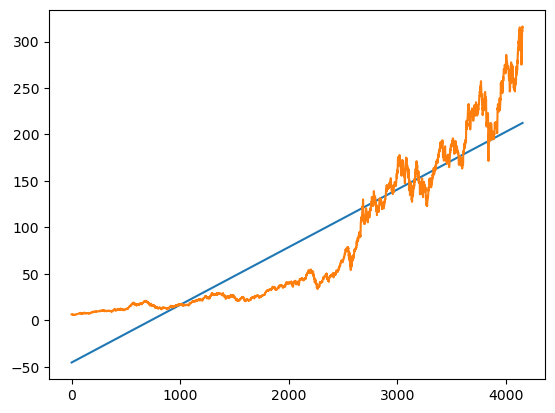

In [72]:
plt.plot(np.arange(len(price)),trendline)
plt.plot(np.arange(len(price)),price)  

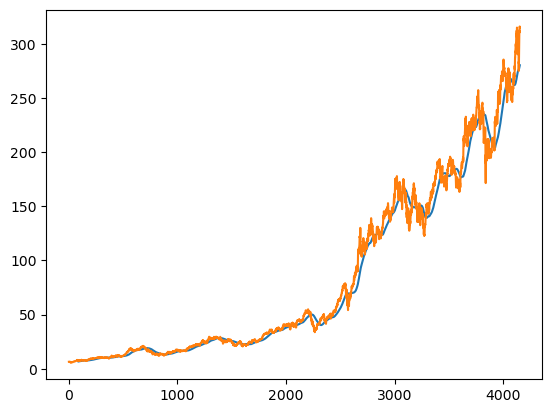

In [75]:

plt.plot(np.arange(len(price)),prices_ma)

plt.plot(np.arange(len(price)),price)

In [76]:
adf_test(prices_adjusted)

Augmented Dickey-Fuller (ADF) Test
ADF Statistic           : 1.764795
p-value                 : 0.998277
Number of Lags Used     : 18
Number of Observations  : 4135

Critical Values:
   1% : -3.431932
   5% : -2.862239
  10% : -2.567142

Conclusion: ❌ Series is NOT Stationary (Fail to Reject H0)
